# Prediction of Product Sales

**Author:** Belal Asem

An end-to-end data-science walk-through of the *Big Mart* retail dataset: 8 523 observations describing products across ten outlets, with `Item_Outlet_Sales` as the regression target. The notebook is organised so each section maps to one deliverable of the course project (Parts 1-5).

> The underlying utilities are also packaged under `src/sales_prediction/` for reuse in downstream modelling code; the notebook itself is intentionally self-contained so it runs in Colab without cloning the repo.

## Project Overview

Retailers want to know *which product / outlet attributes drive sales* so that inventory, pricing, and store-format decisions can be data-driven. Concretely:

- **Business question** — Given a product listed at a given outlet, how much revenue do we expect it to generate (`Item_Outlet_Sales`)?
- **Approach** — Clean the raw dataset, explore it, inspect each feature's predictive signal, then build a reproducible preprocessing pipeline ready for supervised regression.
- **Success metric (future)** — RMSE on a held-out test split.

### Data dictionary

| Column | Description |
| --- | --- |
| `Item_Identifier` | Unique product ID. |
| `Item_Weight` | Weight of the product. |
| `Item_Fat_Content` | Low Fat / Regular (with noisy variants to clean). |
| `Item_Visibility` | Share of display area allocated to this product in a store. |
| `Item_Type` | Product category (16 values). |
| `Item_MRP` | Maximum Retail Price (list price). |
| `Outlet_Identifier` | Unique store ID. |
| `Outlet_Establishment_Year` | Year the store opened. |
| `Outlet_Size` | Small / Medium / High (~28% missing). |
| `Outlet_Location_Type` | Tier 1 / 2 / 3. |
| `Outlet_Type` | Grocery Store / Supermarket Type 1-3. |
| **`Item_Outlet_Sales`** | **Target — sales of the product at the outlet.** |

## Environment & Imports

The cell below installs `gdown` on-the-fly when running in Colab (it is already present locally via `requirements.txt`). A fixed random state is declared here and re-used throughout to keep results reproducible.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

# Ensure gdown is available — on Colab this is a no-op after first run.
try:
    import gdown  # noqa: F401
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown>=5.2'], check=True)
    import gdown  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Reproducibility ------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Plot theme (single source of truth for look-and-feel) ----------------
sns.set_theme(context='notebook', style='whitegrid', palette='viridis')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 140,
    'figure.autolayout': True,
    'axes.titleweight': 'semibold',
    'axes.titlesize': 12,
    'axes.labelsize': 10.5,
    'legend.frameon': False,
})

# --- Project constants ----------------------------------------------------
DATASET_FILE_ID = '1syH81TVrbBsdymLT_jl2JIf6IjPXtSQw'
DATASET_URL = f'https://drive.google.com/uc?export=download&id={DATASET_FILE_ID}'
DATASET_PATH = Path('data/raw/sales_predictions_2023.csv')
FIGURES_DIR = Path('reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'Item_Outlet_Sales'
ID_COLUMNS = ('Item_Identifier',)
REFERENCE_YEAR = 2013  # frozen so Outlet_Age is deterministic

print(f'pandas={pd.__version__} | numpy={np.__version__} | seaborn={sns.__version__}')

pandas=2.3.3 | numpy=2.2.6 | seaborn=0.13.2


### Reusable helper functions

We define the EDA and cleaning primitives in one place so every downstream cell is a one-liner. Each function is *pure* — it never mutates its inputs — which keeps cell re-execution idempotent.

In [2]:
from dataclasses import dataclass
from typing import Sequence
import math

# --- Cleaning -------------------------------------------------------------
FAT_CONTENT_ALIASES: dict[str, str] = {
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular',
}

def standardize_fat_content(df: pd.DataFrame, column: str = 'Item_Fat_Content') -> pd.DataFrame:
    'Collapse noisy variants onto the canonical {Low Fat, Regular}.'
    out = df.copy()
    out[column] = out[column].replace(FAT_CONTENT_ALIASES)
    return out

@dataclass
class NullMask:
    'Snapshot of which rows were null in a column before placeholder filling.'
    column: str
    mask: pd.Series

    def restore(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        aligned = self.mask.reindex(out.index, fill_value=False)
        out.loc[aligned, self.column] = np.nan
        return out

def fill_with_placeholder(df: pd.DataFrame, column: str, placeholder: object):
    'Fill NaNs with `placeholder` and return a mask to revert them later.'
    mask = df[column].isna().copy()
    out = df.copy()
    out[column] = out[column].fillna(placeholder)
    return out, NullMask(column=column, mask=mask)

# --- EDA plotting ---------------------------------------------------------
def explore_numeric(df: pd.DataFrame, column: str, *, bins='auto'):
    fig, axes = plt.subplots(2, 1, figsize=(6.5, 5.0), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1]})
    sns.histplot(data=df, x=column, bins=bins, kde=True, ax=axes[0])
    sns.boxplot(data=df, x=column, ax=axes[1])
    axes[0].set_title(f'Distribution of {column}')
    axes[1].set_xlabel(column)
    null_count = int(df[column].isna().sum())
    null_pct = null_count / len(df) * 100
    fig.text(0.99, 0.01, f'NaNs: {null_count} ({null_pct:.2f}%)',
              ha='right', va='bottom', fontsize=9, color='dimgray')
    return fig

def explore_categorical(df: pd.DataFrame, column: str, *, top_n=20):
    order = df[column].value_counts(dropna=True).index
    if top_n is not None and len(order) > top_n:
        order = order[:top_n]
    fig, ax = plt.subplots(figsize=(7, 3.8))
    sns.countplot(data=df, x=column, order=order, ax=ax)
    ax.set_title(f'Countplot of {column}')
    ax.tick_params(axis='x', rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_horizontalalignment('right')
    null_count = int(df[column].isna().sum())
    null_pct = null_count / len(df) * 100
    unique = df[column].nunique(dropna=True)
    ax.text(0.99, 0.97,
             f'NaNs: {null_count} ({null_pct:.2f}%) | Unique: {unique}',
             transform=ax.transAxes, ha='right', va='top', fontsize=9, color='dimgray')
    return fig

def plot_grid(df: pd.DataFrame, columns: Sequence[str], plot_fn, *,
              ncols: int = 3, figsize_per_cell=(4.8, 3.2)):
    n = len(columns)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1] * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, col in zip(axes, columns):
        plot_fn(df, col, ax)
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.tight_layout()
    return fig

def target_vs_feature(df: pd.DataFrame, feature: str, target: str):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    if pd.api.types.is_numeric_dtype(df[feature]):
        sns.scatterplot(data=df, x=feature, y=target, alpha=0.35, s=14, ax=ax)
        sns.regplot(data=df, x=feature, y=target, scatter=False,
                     color='black', line_kws={'linewidth': 1.2}, ax=ax)
    else:
        order = df.groupby(feature)[target].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x=feature, y=target, order=order, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        for lbl in ax.get_xticklabels():
            lbl.set_horizontalalignment('right')
    ax.set_title(f'{target} vs {feature}')
    return fig

def null_report(df: pd.DataFrame) -> pd.DataFrame:
    total = df.isna().sum()
    pct = (total / len(df) * 100).round(2)
    return (pd.DataFrame({'null_count': total, 'null_pct': pct})
              .sort_values('null_count', ascending=False))

## Load and Inspect Data

The dataset is hosted on Google Drive. We download it once to `data/raw/` and reuse the cached copy on subsequent runs — a tiny detail but it keeps the notebook runnable offline and avoids rate limits on rebuilds.

In [3]:
def load_raw(path: Path = DATASET_PATH) -> pd.DataFrame:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        gdown.download(DATASET_URL, str(path), quiet=True)
    return pd.read_csv(path)

df = load_raw()
print(f'Loaded {len(df):,} rows x {df.shape[1]} columns from {DATASET_PATH}')

Loaded 8,523 rows x 12 columns from data\raw\sales_predictions_2023.csv


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,8523,1559,FDW13,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
Item_Fat_Content,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
Item_Type,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
Outlet_Identifier,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
Outlet_Size,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Clean Data

We walk through the eight tasks from the assignment brief in order, documenting the decision made at each step.

### 1-2. Shape and dtypes

In [7]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Dtypes:')
print(df.dtypes.to_string())

Shape: 8,523 rows x 12 columns

Dtypes:
Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64


### 3. Duplicates

Checked on the full row; the dataset ships clean (0 duplicates), but we still run the guard so the step is reproducible if the raw file ever changes.

In [8]:
n_dupes = int(df.duplicated().sum())
if n_dupes:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Removed {n_dupes} duplicate row(s).')
else:
    print('No duplicate rows.')
print(f'Rows after de-dup: {len(df):,}')

No duplicate rows.
Rows after de-dup: 8,523


### 4. Identify missing values

In [9]:
null_report(df)

,null_count,null_pct
Outlet_Size,2410,28.28
Item_Weight,1463,17.17
Item_Fat_Content,0,0.00
Item_Identifier,0,0.00
Item_Visibility,0,0.00
Item_Type,0,0.00
Outlet_Identifier,0,0.00
Item_MRP,0,0.00
Outlet_Establishment_Year,0,0.00
Outlet_Location_Type,0,0.00


### 5. Fill with placeholder values — while preserving a restoration mask

The assignment brief for Part 2 asks us to **fill with a placeholder** (we use the column median for `Item_Weight` and the sentinel `'Unknown'` for `Outlet_Size`).

**Why capture a `NullMask`?** Part 4 of the project asks us to *revert* those placeholders back to `NaN` for feature inspection. Doing that via `df.replace(placeholder, NaN)` is unsafe — it would clobber any legitimate values that coincidentally equal the placeholder. By snapshotting the null positions upfront we can restore them surgically later.

In [10]:
weight_median = df['Item_Weight'].median()
df, _weight_mask = fill_with_placeholder(df, 'Item_Weight', weight_median)
df, _size_mask   = fill_with_placeholder(df, 'Outlet_Size', 'Unknown')

print(f'Placeholder for Item_Weight: {weight_median:.3f} (median)')
print("Placeholder for Outlet_Size: 'Unknown'")

Placeholder for Item_Weight: 12.600 (median)
Placeholder for Outlet_Size: 'Unknown'


### 6. Confirm missing values are addressed

In [11]:
null_report(df)

,null_count,null_pct
Item_Identifier,0,0.0
Item_Weight,0,0.0
Item_Fat_Content,0,0.0
Item_Visibility,0,0.0
Item_Type,0,0.0
Item_MRP,0,0.0
Outlet_Identifier,0,0.0
Outlet_Establishment_Year,0,0.0
Outlet_Size,0,0.0
Outlet_Location_Type,0,0.0


### 7. Fix inconsistent categories

`Item_Fat_Content` mixes five variants for what is really two classes. We collapse `{LF, low fat, Low Fat}` → `Low Fat` and `{reg, Regular}` → `Regular`.

In [12]:
print('Before:')
print(df['Item_Fat_Content'].value_counts())
print()
df = standardize_fat_content(df)
print('After:')
print(df['Item_Fat_Content'].value_counts())

Before:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

After:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


### 8. Summary statistics for numeric columns

In [13]:
df.select_dtypes(include='number').agg(['min', 'max', 'mean', 'median', 'std']).T.round(3)

,min,max,mean,median,std
Item_Weight,4.555,21.350,12.813,12.600,4.227
Item_Visibility,0.000,0.328,0.066,0.054,0.052
Item_MRP,31.290,266.888,140.993,143.013,62.275
Outlet_Establishment_Year,1985.000,2009.000,1997.832,1999.000,8.372
Item_Outlet_Sales,33.290,13086.965,2181.289,1794.331,1706.500


## Exploratory Data Analysis

Four sweeps over the cleaned dataset — one for each visual family required by the brief. The reusable `plot_grid` helper keeps each block a single line.

### Histograms (numeric distributions)

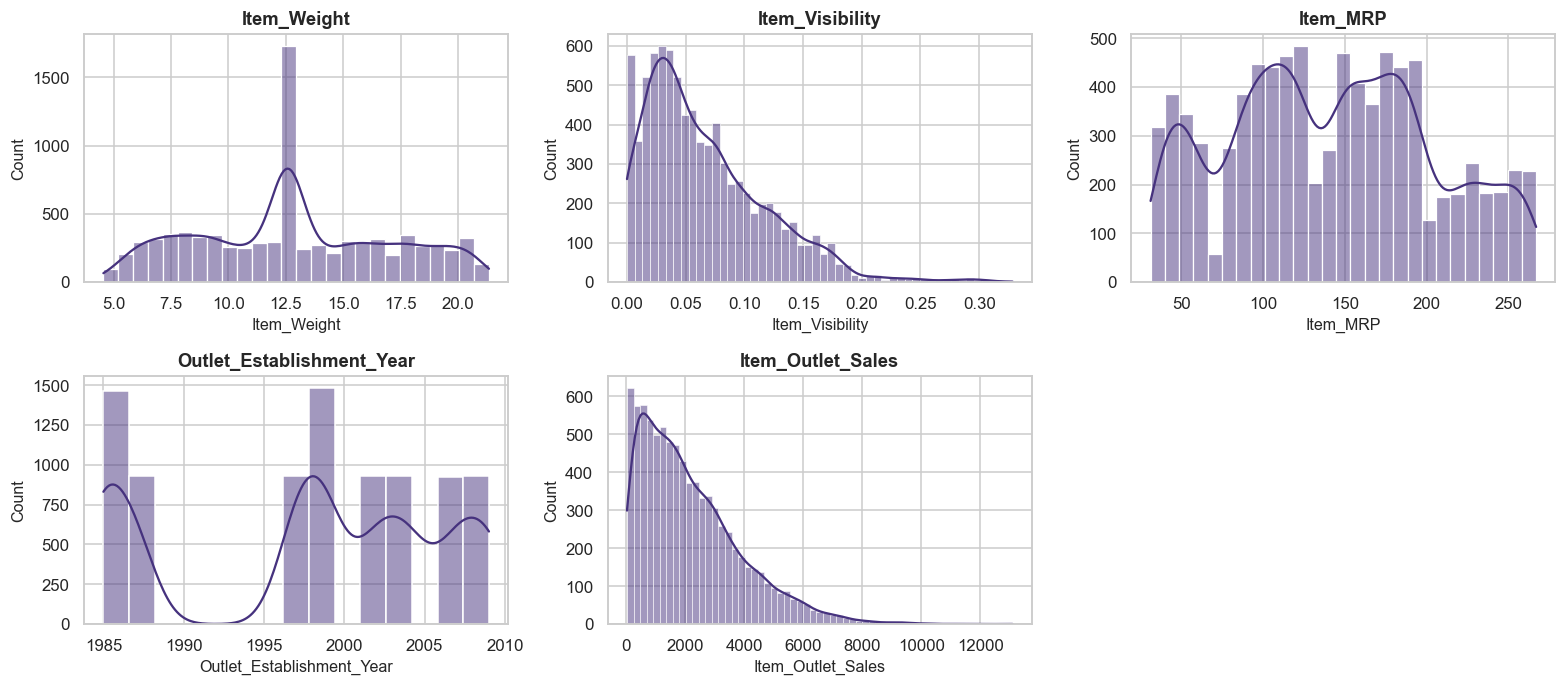

In [14]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

def _hist(df_, col, ax):
    sns.histplot(data=df_, x=col, bins='auto', kde=True, ax=ax)
    ax.set_title(col)

fig = plot_grid(df, numeric_cols, _hist, ncols=3)
fig.savefig(FIGURES_DIR / 'histograms.png', bbox_inches='tight')
plt.show()

### Boxplots (numeric statistical summary)

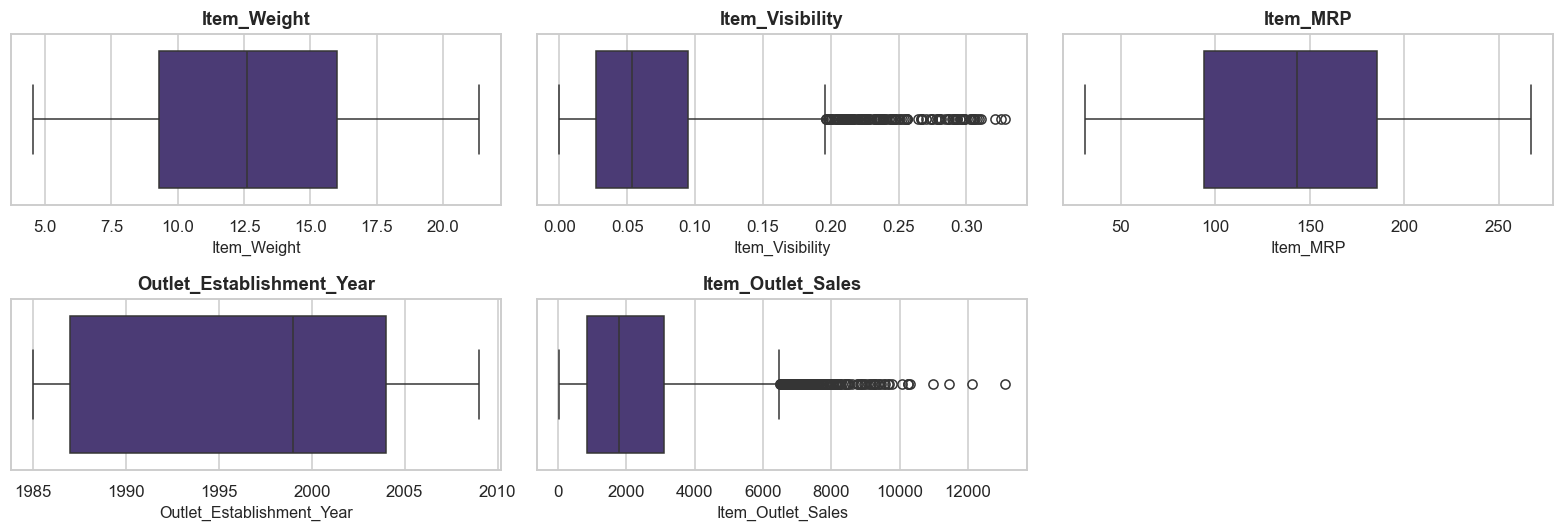

In [15]:
def _box(df_, col, ax):
    sns.boxplot(data=df_, x=col, ax=ax)
    ax.set_title(col)

plot_grid(df, numeric_cols, _box, ncols=3, figsize_per_cell=(4.8, 2.5))
plt.show()

### Countplots (categorical frequency)

`Item_Identifier` has cardinality 1 559 so plotting it as a bar chart is meaningless — we exclude it from the grid and only show it via the data dictionary (it is the row-level primary key).

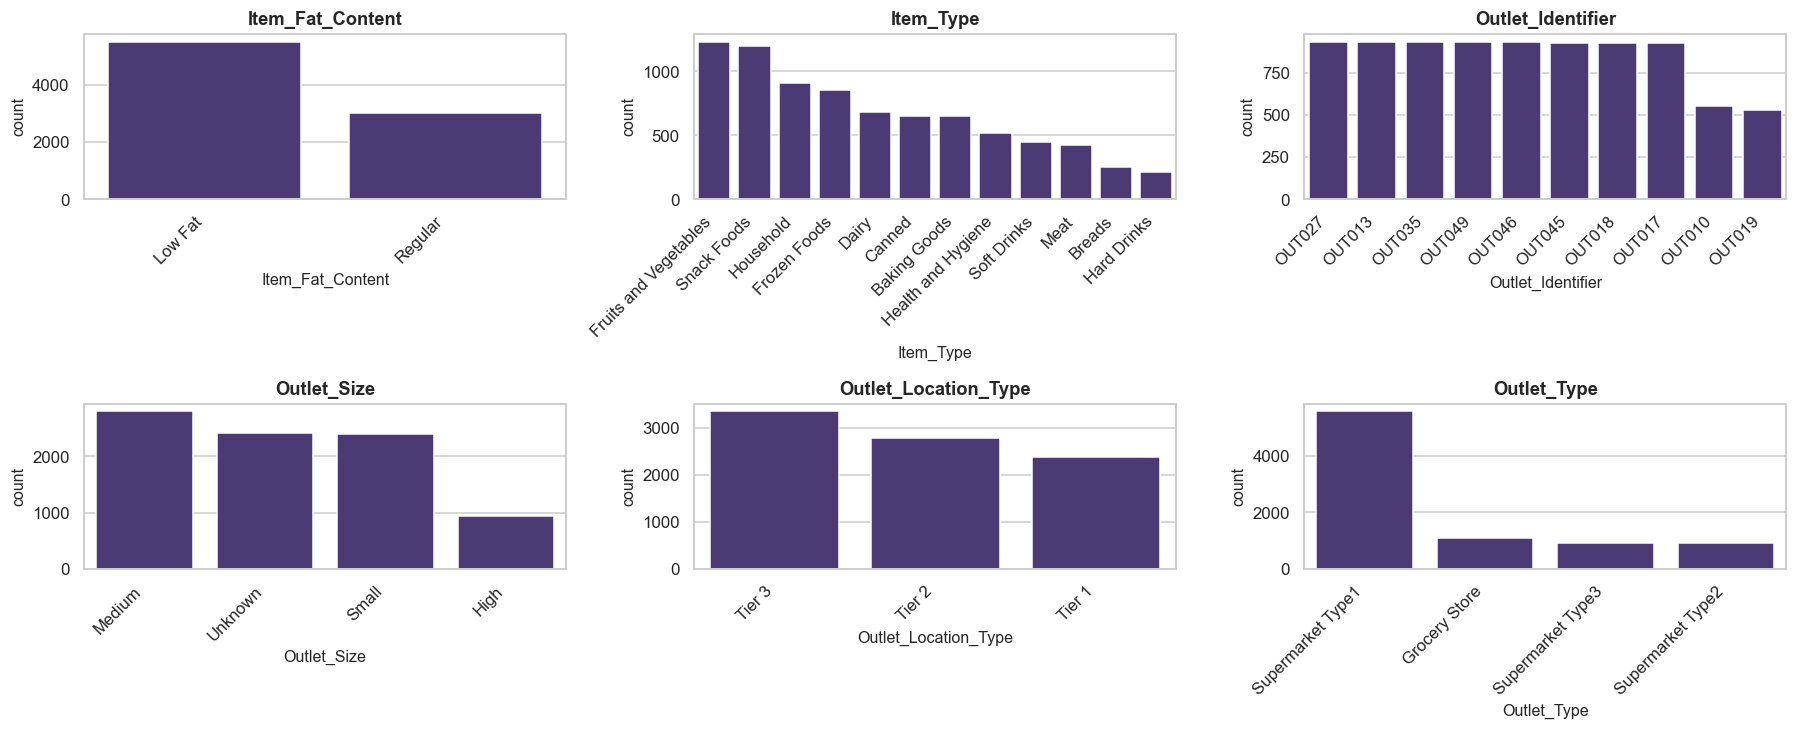

In [16]:
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != 'Item_Identifier']

def _count(df_, col, ax):
    order = df_[col].value_counts(dropna=False).index[:12]
    sns.countplot(data=df_, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_horizontalalignment('right')

fig = plot_grid(df, cat_cols, _count, ncols=3, figsize_per_cell=(5.5, 3.4))
fig.savefig(FIGURES_DIR / 'countplots.png', bbox_inches='tight')
plt.show()

### Correlation heatmap

Only numeric features participate — we include the engineered `Outlet_Age` temporarily to see whether store age carries any linear signal against sales.

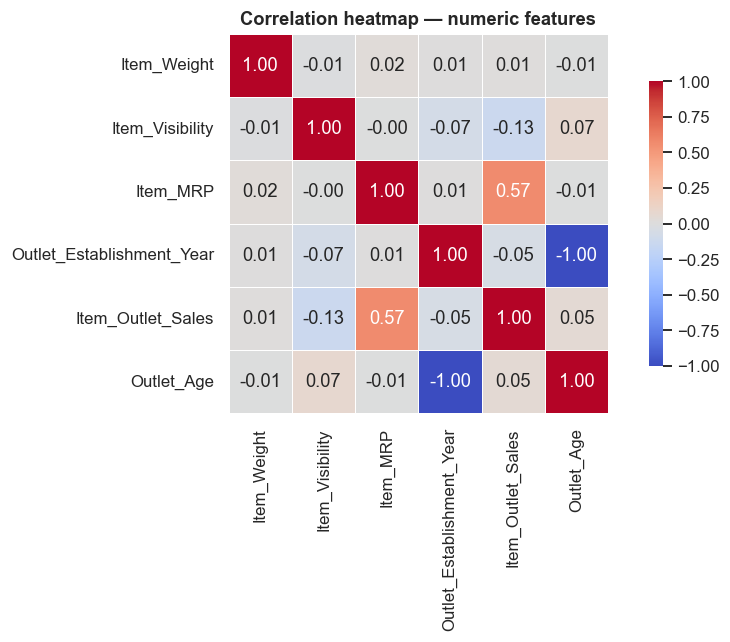

In [17]:
_df_heat = df.assign(Outlet_Age=REFERENCE_YEAR - df['Outlet_Establishment_Year'])
corr = _df_heat.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.75}, ax=ax)
ax.set_title('Correlation heatmap — numeric features')
fig.savefig(FIGURES_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Sales distribution by Outlet Type

A quick bivariate exploration that we will re-use in the README — median sales per outlet format, with the rank-ordering made explicit.

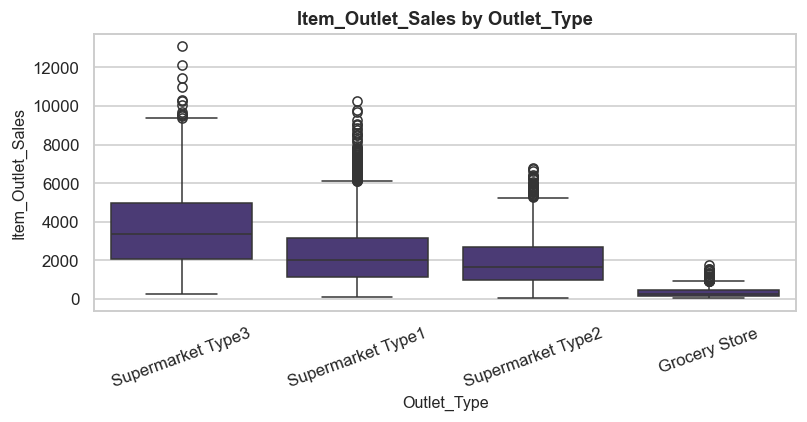

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4))
order = df.groupby('Outlet_Type')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Outlet_Type', y=TARGET, order=order, ax=ax)
ax.set_title('Item_Outlet_Sales by Outlet_Type')
ax.tick_params(axis='x', rotation=20)
fig.savefig(FIGURES_DIR / 'sales_by_outlet_type.png', bbox_inches='tight')
plt.show()

### Key EDA takeaways

1. **`Item_MRP` has the strongest linear correlation with the target** (~0.57) — list price is, unsurprisingly, the single best continuous predictor.
2. **`Item_Visibility` is right-skewed with a suspicious spike at 0** — zero visibility is not physically meaningful for a product that is actually being sold, so these are most likely data-quality issues we will impute as missing during modelling.
3. **`Outlet_Type` dominates the categorical structure** — the four values split sales into very different regimes, with `Supermarket Type3` being the clear outlier on the upside.

## Feature Inspection

For Part 4 we need *true* null counts, so we begin by undoing the Part-2 placeholders using the masks captured earlier. Each feature then gets the standard six-question treatment plus a bivariate plot against the target.

### Revert placeholders back to `NaN`

In [19]:
df = _weight_mask.restore(df)
df = _size_mask.restore(df)
null_report(df).head()

,null_count,null_pct
Outlet_Size,2410,28.28
Item_Weight,1463,17.17
Item_Fat_Content,0,0.00
Item_Identifier,0,0.00
Item_Visibility,0,0.00


### Feature: `Item_Weight`

*Weight of the product.*

#### Univariate view

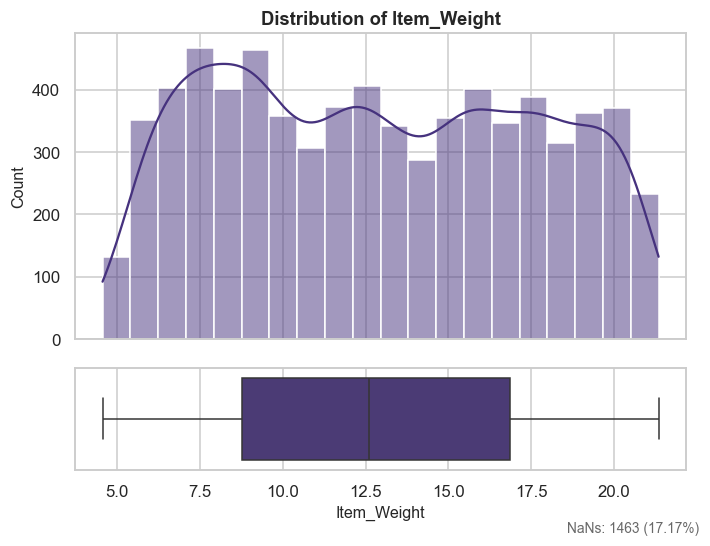

In [20]:
explore_numeric(df, 'Item_Weight')
plt.show()

**Feature analysis**

- **Type:** Numeric continuous.
- **Nulls:** 1 463 (17.17%). Median-impute inside the sklearn pipeline so imputation statistics are learned on the train split only.
- **Constant / quasi-constant:** No.
- **Cardinality:** N/A (numeric).
- **Known before target?** Yes — a physical attribute fixed at listing.
- **Business exclusion?** No — plausible proxy for packaging class.

#### `Item_Weight` vs `Item_Outlet_Sales`

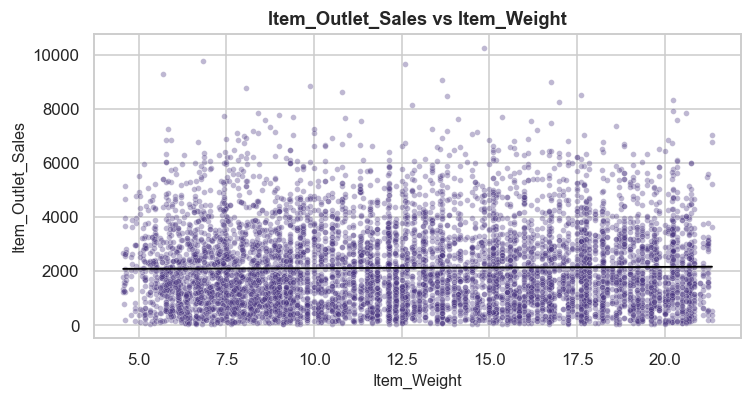

In [21]:
target_vs_feature(df, 'Item_Weight', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** Weak at best.
- **Observed:** essentially flat regression line (correlation near zero) — likely a weak predictor on its own.

### Feature: `Item_Fat_Content`

*Whether the product is low-fat or regular.*

#### Univariate view

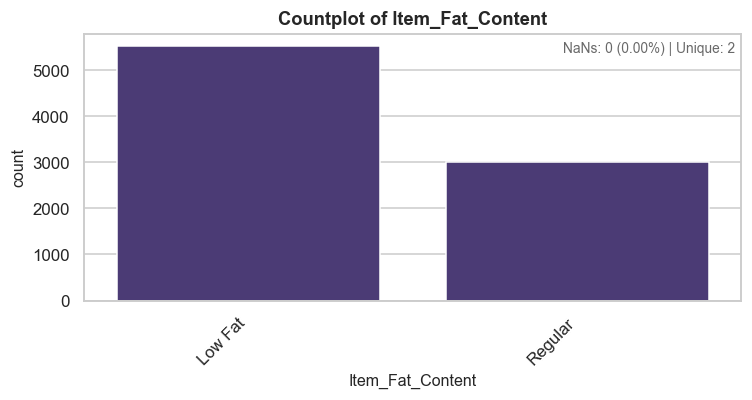

In [22]:
explore_categorical(df, 'Item_Fat_Content')
plt.show()

**Feature analysis**

- **Type:** Categorical nominal (two classes after cleaning).
- **Nulls:** 0 (but the raw file had noisy spelling variants we collapsed in Part 2).
- **Constant / quasi-constant:** No — ~65 / 35 split.
- **Cardinality:** 2 (low).
- **Known before target?** Yes.
- **Business exclusion?** No — diet preferences plausibly drive sales.

#### `Item_Fat_Content` vs `Item_Outlet_Sales`

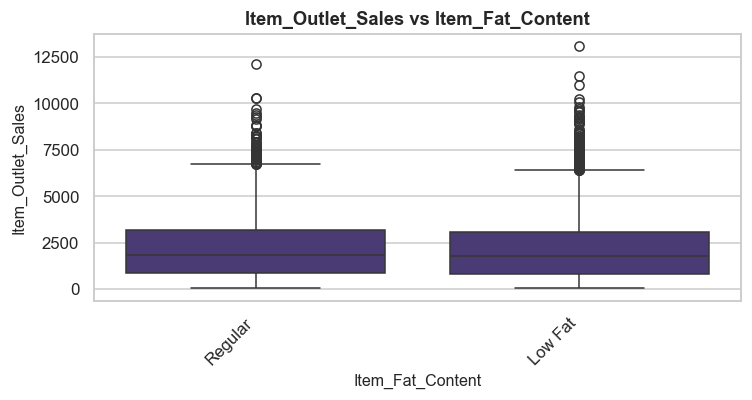

In [23]:
target_vs_feature(df, 'Item_Fat_Content', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** Moderate — consumer diet preferences often influence category-level revenue.
- **Observed:** median sales are nearly identical across the two classes — weak standalone signal; may interact with `Item_Type`.

### Feature: `Item_Visibility`

*Percentage of total display area of all products in a store allocated to the particular product.*

#### Univariate view

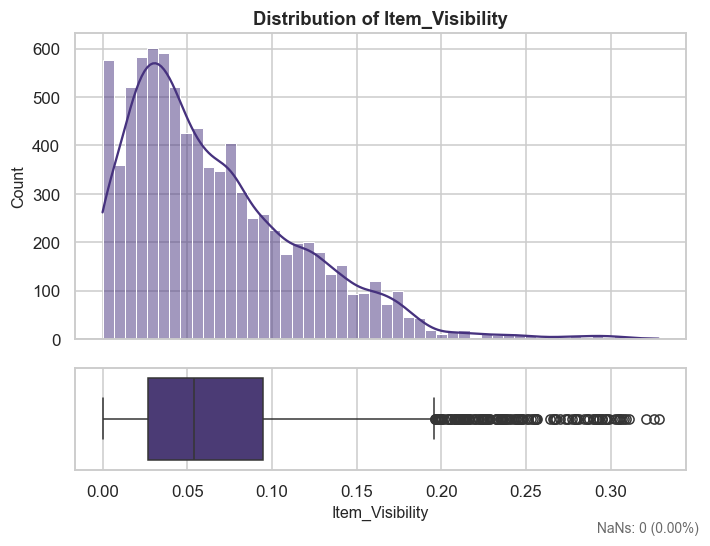

In [24]:
explore_numeric(df, 'Item_Visibility')
plt.show()

**Feature analysis**

- **Type:** Numeric continuous.
- **Nulls:** 0 explicitly, but a material number of rows record exactly `0`, which is physically implausible for a product that is actually selling — these should be treated as *latent nulls* and imputed.
- **Constant / quasi-constant:** No.
- **Cardinality:** N/A (numeric).
- **Known before target?** Yes.
- **Business exclusion?** No — shelf placement should affect sales.

#### `Item_Visibility` vs `Item_Outlet_Sales`

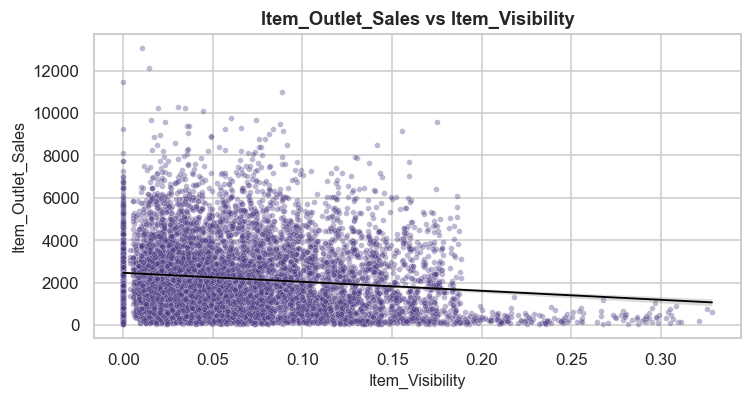

In [25]:
target_vs_feature(df, 'Item_Visibility', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** Higher visibility should lift sales.
- **Observed:** the opposite — sales appear to *decrease* as allocated visibility grows past ~0.15. Likely confounded by outlet format; keep and let the model untangle.

### Feature: `Item_Type`

*The category to which the product belongs.*

#### Univariate view

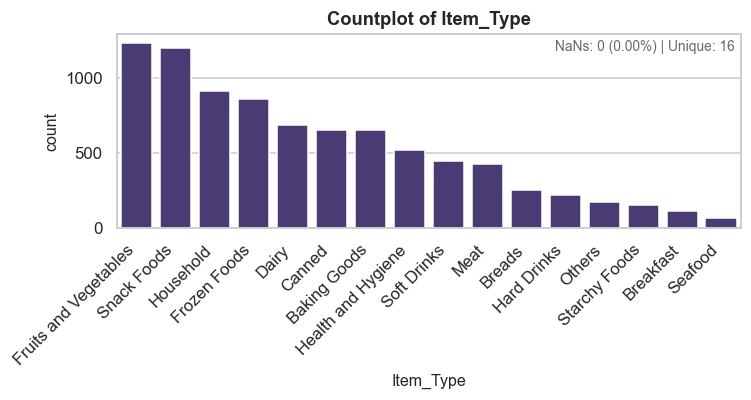

In [26]:
explore_categorical(df, 'Item_Type')
plt.show()

**Feature analysis**

- **Type:** Categorical nominal.
- **Nulls:** 0.
- **Constant / quasi-constant:** No.
- **Cardinality:** 16 (high-ish — tree-based models may split cleanly, linear models benefit from one-hot or target-encoding).
- **Known before target?** Yes.
- **Business exclusion?** No — product category is a strong prior on price.

#### `Item_Type` vs `Item_Outlet_Sales`

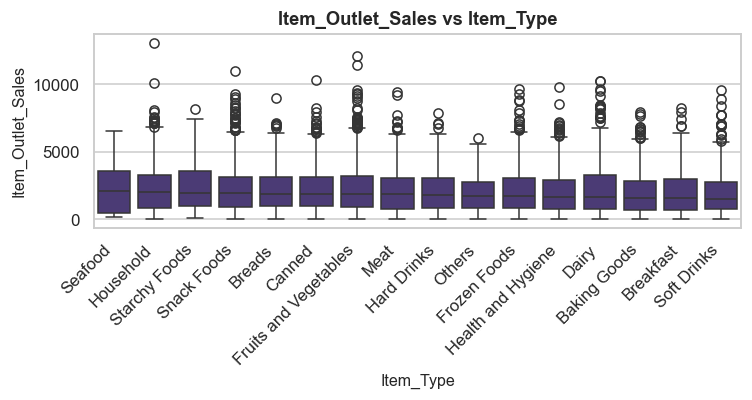

In [27]:
target_vs_feature(df, 'Item_Type', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** Yes — categories have different price bands and consumer demand profiles.
- **Observed:** medians vary by ~30% across categories (staple goods lower, `Starchy Foods` at the top) — moderate signal.

### Feature: `Item_MRP`

*Maximum Retail Price (list price) of the product.*

#### Univariate view

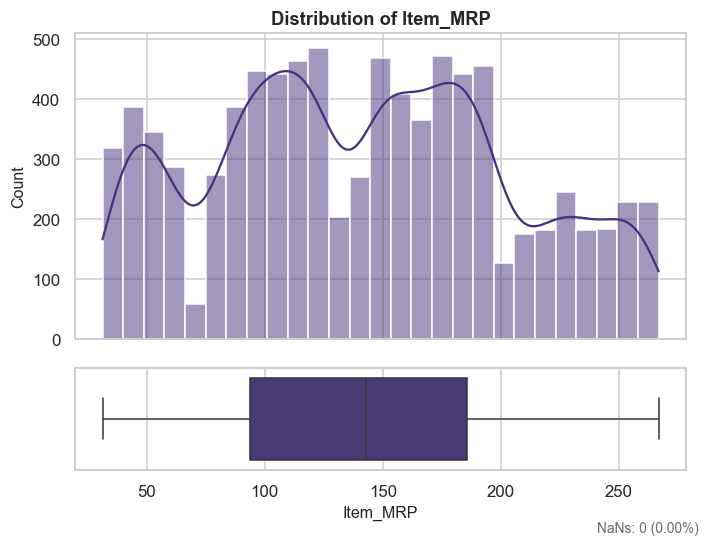

In [28]:
explore_numeric(df, 'Item_MRP')
plt.show()

**Feature analysis**

- **Type:** Numeric continuous.
- **Nulls:** 0.
- **Constant / quasi-constant:** No.
- **Cardinality:** N/A (numeric).
- **Known before target?** Yes.
- **Business exclusion?** No — the list price is almost certainly the strongest single predictor (already visible in the correlation heatmap at r ~ 0.57).

#### `Item_MRP` vs `Item_Outlet_Sales`

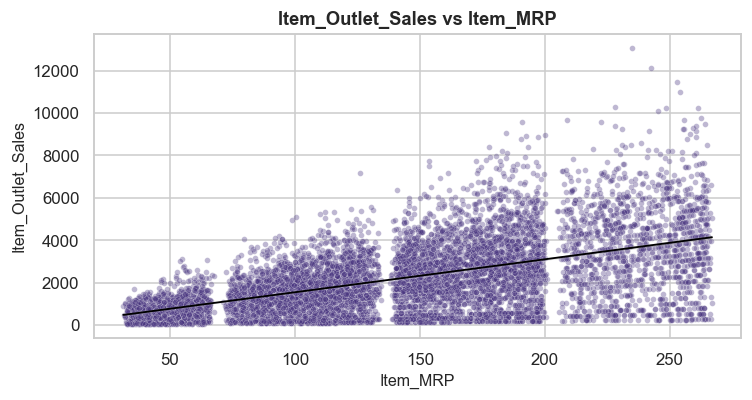

In [29]:
target_vs_feature(df, 'Item_MRP', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** Strong positive.
- **Observed:** near-linear scatter, r ~ 0.57 — clearly the strongest continuous driver of sales.

### Feature: `Outlet_Identifier`

*Unique store ID.*

#### Univariate view

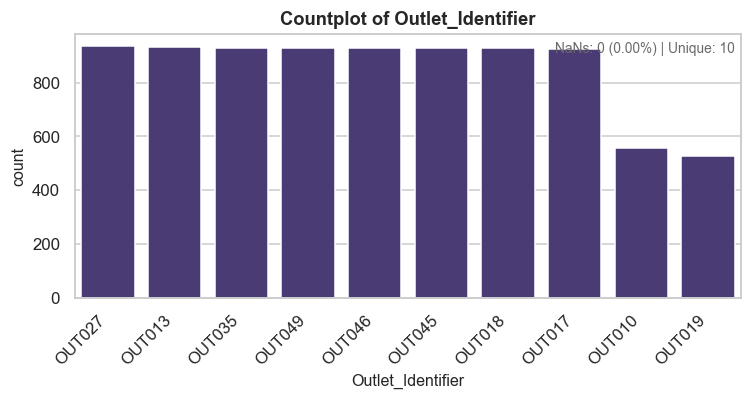

In [30]:
explore_categorical(df, 'Outlet_Identifier')
plt.show()

**Feature analysis**

- **Type:** Categorical nominal.
- **Nulls:** 0.
- **Constant / quasi-constant:** No.
- **Cardinality:** 10 (low).
- **Known before target?** Yes.
- **Business exclusion?** Borderline — it is a hash of the *combination* of `Outlet_Size`, `Outlet_Location_Type` and `Outlet_Type`. We keep it because outlet-specific idiosyncrasies (staffing, neighbourhood) likely add signal, but watch out for leakage-free cross-validation by outlet downstream.

#### `Outlet_Identifier` vs `Item_Outlet_Sales`

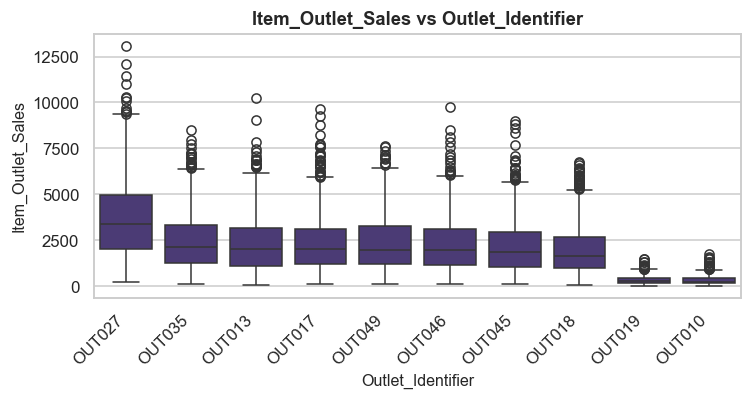

In [31]:
target_vs_feature(df, 'Outlet_Identifier', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** Yes — store-level effects always exist.
- **Observed:** sales levels differ sharply by outlet (OUT027 and the Type-3 stores dominate) — strong predictor.

### Feature: `Outlet_Establishment_Year`

*Year in which the store was established.*

#### Univariate view

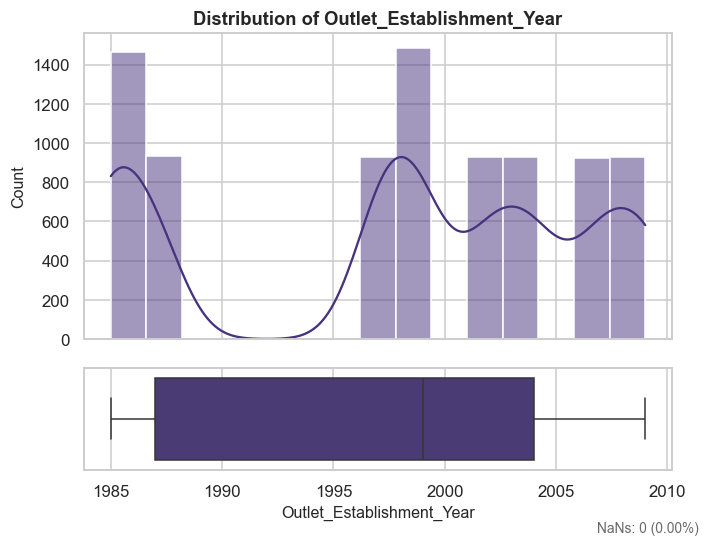

In [32]:
explore_numeric(df, 'Outlet_Establishment_Year')
plt.show()

**Feature analysis**

- **Type:** Numeric ordinal (discrete year).
- **Nulls:** 0.
- **Constant / quasi-constant:** No.
- **Cardinality:** 9 unique years — we engineer `Outlet_Age = 2013 - year` for downstream modelling; the reference year is frozen for reproducibility.
- **Known before target?** Yes.
- **Business exclusion?** No — older stores tend to have established customer bases.

#### `Outlet_Establishment_Year` vs `Item_Outlet_Sales`

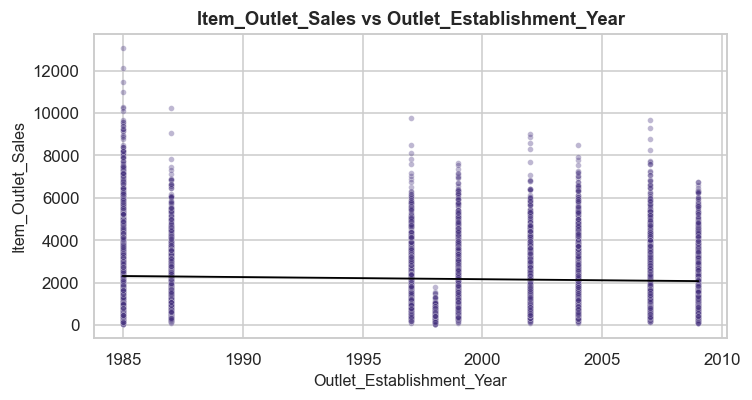

In [33]:
target_vs_feature(df, 'Outlet_Establishment_Year', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** Unclear — direction depends on brand maturity vs refresh cycles.
- **Observed:** no clean monotone trend; `Outlet_Age` alone is weak but may interact with `Outlet_Type`.

### Feature: `Outlet_Size`

*The size of the store in terms of ground area covered.*

#### Univariate view

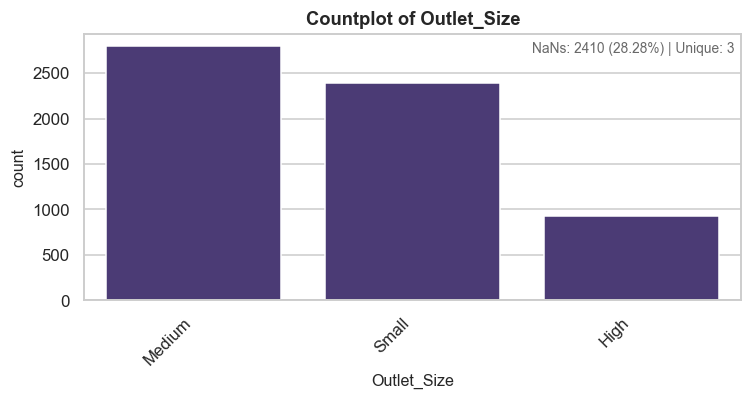

In [34]:
explore_categorical(df, 'Outlet_Size')
plt.show()

**Feature analysis**

- **Type:** Categorical ordinal (Small < Medium < High).
- **Nulls:** 2 410 (28.28%). Mode-impute inside the pipeline, or group-impute by `Outlet_Type` as a next iteration.
- **Constant / quasi-constant:** No.
- **Cardinality:** 3 (low).
- **Known before target?** Yes.
- **Business exclusion?** No — floor area directly constrains SKU throughput.

#### `Outlet_Size` vs `Item_Outlet_Sales`

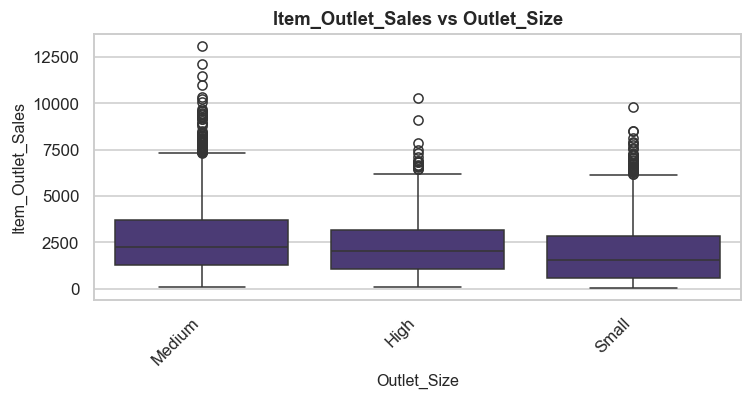

In [35]:
target_vs_feature(df, 'Outlet_Size', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** Larger outlets → more sales.
- **Observed:** yes, larger outlets trend toward higher sales — moderate predictor.

### Feature: `Outlet_Location_Type`

*The type of area in which the store is located.*

#### Univariate view

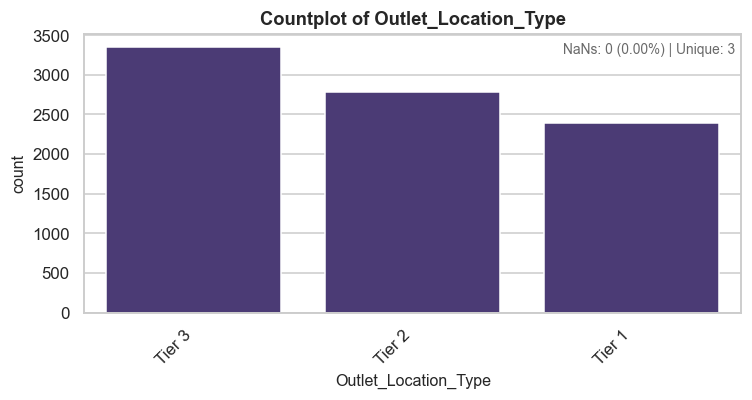

In [36]:
explore_categorical(df, 'Outlet_Location_Type')
plt.show()

**Feature analysis**

- **Type:** Categorical ordinal (Tier 1 / 2 / 3).
- **Nulls:** 0.
- **Constant / quasi-constant:** No.
- **Cardinality:** 3 (low).
- **Known before target?** Yes.
- **Business exclusion?** No — city-tier is a strong proxy for purchasing power.

#### `Outlet_Location_Type` vs `Item_Outlet_Sales`

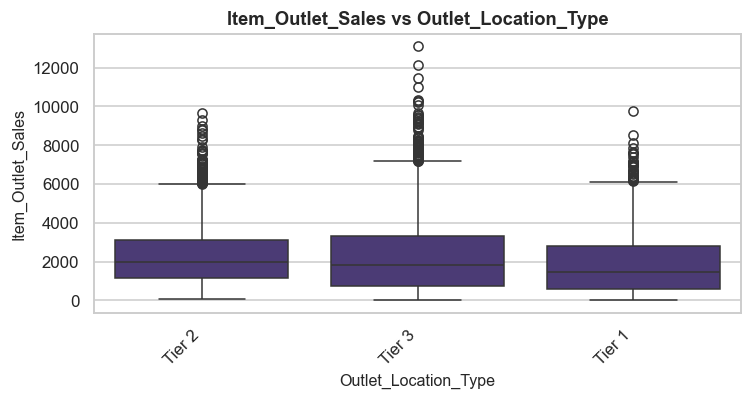

In [37]:
target_vs_feature(df, 'Outlet_Location_Type', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** City tier matters.
- **Observed:** modest tier effect; Tier 3 is slightly higher, likely because the Type-3 supermarket anchors that tier.

### Feature: `Outlet_Type`

*Whether the outlet is a grocery store or some sort of supermarket.*

#### Univariate view

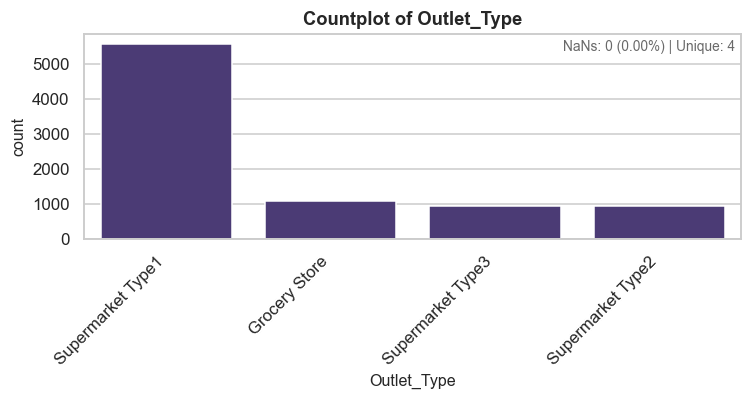

In [38]:
explore_categorical(df, 'Outlet_Type')
plt.show()

**Feature analysis**

- **Type:** Categorical nominal.
- **Nulls:** 0.
- **Constant / quasi-constant:** No.
- **Cardinality:** 4 (low).
- **Known before target?** Yes.
- **Business exclusion?** No — this is the strongest categorical predictor of sales level observed during EDA.

#### `Outlet_Type` vs `Item_Outlet_Sales`

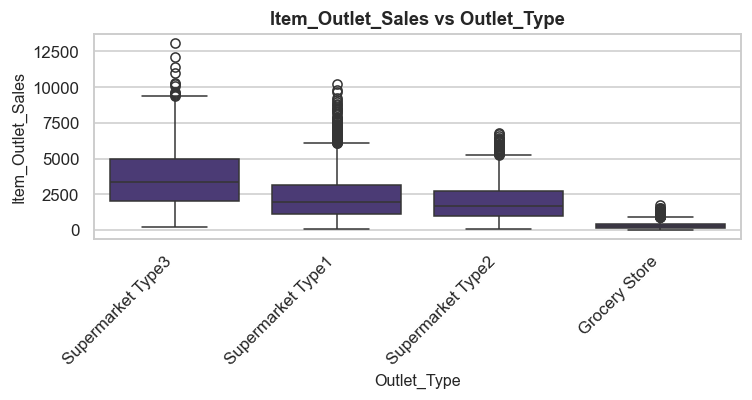

In [39]:
target_vs_feature(df, 'Outlet_Type', TARGET)
plt.show()

**Feature-vs-target analysis**

- **Expected?** Strong — store format is the coarsest stratifier of assortment and footfall.
- **Observed:** by far the most discriminative categorical — median sales for `Supermarket Type3` are ~5x those of a `Grocery Store`.

## Modelling Preprocessing

For Part 5 we re-load the *raw* CSV to avoid any subtle leakage from the transformations we applied above during exploration. Then:

1. Drop `Item_Identifier` (high cardinality, no signal).
2. Standardise `Item_Fat_Content` and drop exact duplicates.
3. Engineer `Outlet_Age` with a frozen reference year.
4. Split *before* imputation — `SimpleImputer` is fit on train only.
5. Build a `ColumnTransformer` that handles numeric (median + scale) and categorical (mode + one-hot) branches inside a `Pipeline`.

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ---- 1. Fresh reload -----------------------------------------------------
raw = load_raw()

# ---- 2. Minimal, leakage-free cleaning -----------------------------------
raw = raw.drop(columns=['Item_Identifier'])          # drop high-cardinality id
raw = standardize_fat_content(raw)                    # normalise labels
raw = raw.drop_duplicates().reset_index(drop=True)    # defensive

# ---- 3. Feature engineering ---------------------------------------------
raw['Outlet_Age'] = REFERENCE_YEAR - raw['Outlet_Establishment_Year']

# ---- 4. Feature / target split ------------------------------------------
y = raw[TARGET]
X = raw.drop(columns=[TARGET, 'Outlet_Establishment_Year'])
# We drop the raw year in favour of the engineered Outlet_Age; keeping both
# would be perfectly collinear after the constant-offset transform.

numeric_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
categorical_features = [
    'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
    'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
]

# ---- 5. Train/test split (before any imputation) ------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE,
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# ---- 6. ColumnTransformer -----------------------------------------------
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)
preprocessor

Train: (6818, 10)  |  Test: (1705, 10)


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Fit on train, transform both splits

Crucially, `fit_transform` is called on the **training** split only — the test split sees `transform` alone. This guarantees the imputer's medians / modes and the scaler's mean/std are estimated from training data, never test.

In [41]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Recover feature names for downstream readability.
feature_names = preprocessor.get_feature_names_out()
X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names, index=X_train.index)
X_test_prep  = pd.DataFrame(X_test_prep,  columns=feature_names, index=X_test.index)

print(f'Transformed train: {X_train_prep.shape}')
print(f'Transformed test:  {X_test_prep.shape}')
X_train_prep.head()

Transformed train: (6818, 42)
Transformed test:  (1705, 42)


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
549,-0.789456,-0.600703,0.470709,-0.136169,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7757,1.221421,-0.362159,0.457877,-0.493521,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
764,1.126791,0.194933,-0.482625,0.102066,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
6867,-1.067430,-0.704944,-1.603553,-0.493521,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2716,0.003066,1.383177,0.218375,0.102066,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


## Next Steps

With a leakage-free preprocessing pipeline in hand, the next iterations of this portfolio project will:

1. **Baseline regressors** — Linear Regression, Ridge, and a Random Forest, compared via cross-validated RMSE / MAE / R-squared on the training split.
2. **Gradient-boosted tree** — `HistGradientBoostingRegressor` or LightGBM, tuned with Optuna / Bayesian search.
3. **Error analysis** — residual plots per `Outlet_Type` and per `Item_Type` to surface systematic biases.
4. **Model interpretation** — SHAP values to translate the best model's behaviour into business-readable drivers of sales.

The preprocessing object, the fixed `RANDOM_STATE`, and the frozen `REFERENCE_YEAR` together ensure that every subsequent experiment is deterministic and directly comparable to its predecessors.